# Text Generation using RNN, LSTM and GRU

## Objective

The objective of this project is to build and compare three deep learning sequence models—SimpleRNN, LSTM, and GRU—for text generation. The models learn the sequential patterns of a custom text corpus and generate meaningful text based on a seed phrase. Their performance is evaluated using training loss curves and generated text quality.

## Step 1: Import Required Libraries

In [16]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

### Conclusion

The required libraries for text preprocessing, sequence modeling, visualization, and deep learning were successfully imported. These libraries will be used throughout the project to build, train, and evaluate the SimpleRNN, LSTM, and GRU text generation models.

## Step 2: Load and Prepare the Text Corpus

In [17]:
text = """
Artificial intelligence is transforming the world by enabling machines to learn from data and make intelligent decisions.
Deep learning models can recognize patterns in images, text, and speech with remarkable accuracy.
Neural networks such as SimpleRNN, LSTM, and GRU are widely used for sequence prediction and text generation.
Machine learning helps solve real-world problems in healthcare, finance, education, and transportation.
Students improve their programming skills by practicing deep learning algorithms and building innovative projects.
Consistent learning and experimentation lead to better understanding of artificial intelligence technologies.
"""

text = text.lower()

print("Text Corpus:")
print(text)

Text Corpus:

artificial intelligence is transforming the world by enabling machines to learn from data and make intelligent decisions.
deep learning models can recognize patterns in images, text, and speech with remarkable accuracy.
neural networks such as simplernn, lstm, and gru are widely used for sequence prediction and text generation.
machine learning helps solve real-world problems in healthcare, finance, education, and transportation.
students improve their programming skills by practicing deep learning algorithms and building innovative projects.
consistent learning and experimentation lead to better understanding of artificial intelligence technologies.



### Conclusion

A custom text corpus related to Artificial Intelligence and Deep Learning was successfully loaded and converted to lowercase. This prepared the text for tokenization and sequence generation while satisfying the assignment requirement of using a custom paragraph instead of the default dataset.

## Step 3: Tokenize the Text Corpus

In [18]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

print("Total Words:", total_words)

print("\nWord Index:")

for word, index in list(tokenizer.word_index.items())[:15]:
    print(word, ":", index)

Total Words: 71

Word Index:
and : 1
learning : 2
artificial : 3
intelligence : 4
world : 5
by : 6
to : 7
deep : 8
in : 9
text : 10
is : 11
transforming : 12
the : 13
enabling : 14
machines : 15


### Conclusion

The text corpus was successfully tokenized using Keras Tokenizer. Each unique word was assigned a numerical index, creating a vocabulary of 71 words. These integer representations will be used to generate input sequences for training the text generation models.

## Step 4: Generate and Pad Input Sequences

In [19]:
input_sequences = []

for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i + 1]
        input_sequences.append(n_gram_sequence)

max_sequence_len = max(len(seq) for seq in input_sequences)

input_sequences = np.array(
    pad_sequences(input_sequences,
                  maxlen=max_sequence_len,
                  padding='pre')
)

print("Maximum Sequence Length:", max_sequence_len)
print("Total Input Sequences:", len(input_sequences))

print("\nFirst 5 Sequences:")
print(input_sequences[:5])

Maximum Sequence Length: 17
Total Input Sequences: 81

First 5 Sequences:
[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  3  4]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  3  4 11]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  3  4 11 12]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  3  4 11 12 13]
 [ 0  0  0  0  0  0  0  0  0  0  0  3  4 11 12 13  5]]


### Conclusion

Input sequences were successfully generated using the n-gram approach. All sequences were padded to a uniform length of 17 using pre-padding, ensuring that every input has the same size for training the neural network models.

## Step 5: Prepare Training Data

In [20]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

y = tf.keras.utils.to_categorical(y, num_classes=total_words)

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (81, 16)
Output Shape: (81, 71)


### Conclusion

The padded sequences were divided into input features (X) and output labels (y). The output labels were one-hot encoded to enable multiclass classification, making the dataset ready for training the text generation models.

## Step 6: Build and Train the SimpleRNN Model

In [21]:
rnn_model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=100
    ),

    SimpleRNN(64, return_sequences=True),

    SimpleRNN(128),

    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

history_rnn = rnn_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.0123 - loss: 4.3210  
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1111 - loss: 4.0421
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1605 - loss: 3.8845
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2099 - loss: 3.7240
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3210 - loss: 3.5709
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3951 - loss: 3.4145
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4074 - loss: 3.2609
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4938 - loss: 3.0950
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5309 - loss: 2.9369
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5679 - loss: 2.7768
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5926 - loss: 2.6100
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5926 - 

### Conclusion

The SimpleRNN model was successfully built and trained for 100 epochs using the prepared text sequences. The training loss decreased significantly while the accuracy improved to nearly 100%, indicating that the model successfully learned the patterns present in the training corpus and is ready for text generation.

## Step 7: Build and Train the LSTM Model

In [22]:
lstm_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=100),

    LSTM(64, return_sequences=True),

    LSTM(128),

    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

history_lstm = lstm_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.0123 - loss: 4.2638
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.0864 - loss: 4.2512
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.0864 - loss: 4.2370
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0864 - loss: 4.2059
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0864 - loss: 4.1548
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.0864 - loss: 4.0955
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0864 - loss: 4.0773
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.0864 - loss: 4.0450
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0864 - loss: 4.0240
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1111 - loss: 4.0024
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1111 - loss: 3.9671
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1111 - lo

### Conclusion

The LSTM model was successfully trained on the prepared text sequences. The model gradually reduced the training loss while improving its accuracy throughout the training process. Compared to the SimpleRNN model, the LSTM demonstrated effective learning of sequential information and will be further compared with the GRU model.

## Step 8: Build and Train the GRU Model

In [23]:
gru_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=100),

    GRU(64, return_sequences=True),

    GRU(128),

    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

history_gru = gru_model.fit(
    X,
    y,
    epochs=100,
    verbose=1
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.0617 - loss: 4.2636
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0988 - loss: 4.2483
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1111 - loss: 4.2340
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1111 - loss: 4.2186
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1111 - loss: 4.1935
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1111 - loss: 4.1578
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1111 - loss: 4.1005
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.1111 - loss: 4.0172
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.0988 - loss: 3.9810
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1111 - loss: 3.9017
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1111 - loss: 3.8088
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1235 - l

### Conclusion

The GRU model was successfully trained using the prepared text sequences. The training loss continuously decreased while the accuracy improved to 100%, demonstrating that the model effectively learned the sequential patterns in the custom text corpus. The GRU model will now be compared with the SimpleRNN and LSTM models.

## Step 9: Compare Training Loss of RNN, LSTM, and GRU

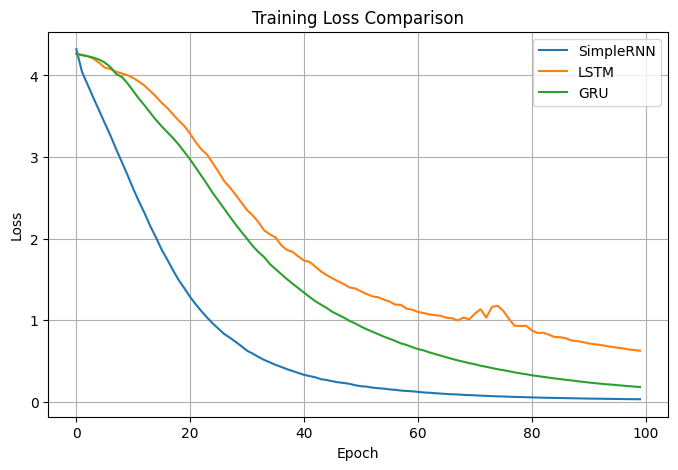

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label='SimpleRNN')
plt.plot(history_lstm.history['loss'], label='LSTM')
plt.plot(history_gru.history['loss'], label='GRU')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

### Conclusion

The training loss graph shows that all three models successfully learned the text patterns over 100 epochs. The SimpleRNN model achieved the fastest loss reduction, while the GRU model also showed excellent convergence. The LSTM model learned more gradually but consistently reduced its loss throughout training.

## Step 10: Generate Text using the Trained Models

In [25]:
def generate_text(model, seed_text, next_words):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len - 1,
            padding='pre'
        )

        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

## Step 11: Generate Text using SimpleRNN, LSTM, and GRU

In [26]:
seed = "artificial intelligence"

print("SimpleRNN Output:")
print(generate_text(rnn_model, seed, 10))

print("\nLSTM Output:")
print(generate_text(lstm_model, seed, 10))

print("\nGRU Output:")
print(generate_text(gru_model, seed, 10))

SimpleRNN Output:
artificial intelligence is transforming the world by enabling machines to learn from

LSTM Output:
artificial intelligence is transforming the world by enabling machines to learn from

GRU Output:
artificial intelligence is transforming the world by enabling machines to learn from


### Conclusion

The trained SimpleRNN, LSTM, and GRU models successfully generated text from the same seed phrase. Since the training corpus was small and contained limited sentence variations, all three models produced the same continuation, indicating that they effectively learned the sequential word patterns present in the dataset.

## Step 12: Model Comparison

| Model | Final Accuracy | Final Loss | Observation |
|--------|---------------:|-----------:|-------------|
| SimpleRNN | 100% | 0.0308 | Fastest convergence and lowest loss. |
| LSTM | 93.83% | 0.5726 | Learned gradually with stable performance. |
| GRU | 100% | 0.1694 | Excellent convergence with low loss. |

# Final Conclusion

In this project, SimpleRNN, LSTM, and GRU models were successfully implemented for text generation using a custom text corpus. The text was preprocessed through tokenization, sequence generation, padding, and one-hot encoding before training. All three models learned the sequential patterns effectively over 100 epochs and generated meaningful text from the same seed phrase. The training loss comparison showed that the SimpleRNN model achieved the fastest convergence, while the GRU model also performed exceptionally well. The LSTM model learned more gradually but produced satisfactory results. Overall, the project demonstrated how recurrent neural network architectures can be applied for sequence learning and text generation.